In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def plot_iv_surface(
    iv_surface: np.ndarray,
    strikes: np.ndarray,
    maturities: np.ndarray,
    xi0_curve: np.ndarray = None,
    xi0_knots_times: np.ndarray = None,
    kind: str = "contour",
    cmap: str = "plasma",
    figsize=(10, 6),
    title: str = "Implied Volatility Surface",
    log_maturity: bool = True,
):
    """
    Plot implied volatility surface with optional ξ₀(t) forward variance curve across maturities.

    Parameters
    ----------
    iv_surface : np.ndarray
        2D implied vol array (n_maturities, n_strikes).
    strikes : np.ndarray
        1D strike grid.
    maturities : np.ndarray
        1D maturity grid.
    xi0_curve : np.ndarray, optional
        Forward variance values corresponding to xi0_knots_times.
    xi0_knots_times : np.ndarray, optional
        Time points for the xi0_curve. If None, assumed to be equally spaced over maturities.
    kind : {"contour", "heatmap"}, default "contour"
        Plot style.
    cmap : str, default "plasma"
        Colormap.
    figsize : tuple, default (10, 6)
        Figure size.
    title : str, default "Implied Volatility Surface"
        Title of the plot.
    log_maturity : bool, default True
        Whether to plot maturities on log scale.
    """

    maturities = np.array(maturities, dtype=float)
    strikes = np.array(strikes, dtype=float)
    K, T = np.meshgrid(strikes, maturities)

    # --- Main IV surface plot ---
    fig, ax = plt.subplots(figsize=figsize)

    if kind == "heatmap":
        im = ax.imshow(
            iv_surface,
            extent=[strikes.min(), strikes.max(), maturities.min(), maturities.max()],
            origin="lower",
            aspect="auto",
            cmap=cmap,
        )
        cbar = fig.colorbar(im, ax=ax, label="Implied Volatility")
    elif kind == "contour":
        contour = ax.contourf(K, T, iv_surface, levels=20, cmap=cmap)
        cbar = fig.colorbar(contour, ax=ax, label="Implied Volatility")
    else:
        raise ValueError(f"Unknown kind '{kind}'")

    ax.set_xlabel("Strike")
    ax.set_ylabel("Maturity (Years)")
    ax.set_title(title)
    if log_maturity:
        ax.set_yscale("log")

    # --- ξ₀(t) overlay along maturity ---
    if xi0_curve is not None:
        if xi0_knots_times is None:
            xi0_knots_times = np.linspace(0, maturities[-1], len(xi0_curve))

        # interpolate to match maturity grid
        interp_xi0 = interp1d(
            xi0_knots_times, xi0_curve, kind="previous", fill_value="extrapolate"
        )
        xi0_interp = interp_xi0(maturities)

        # normalize to fit visually within the color scale
        normed_xi0 = (xi0_interp - xi0_interp.min()) / (xi0_interp.max() - xi0_interp.min() + 1e-12)
        normed_xi0 = normed_xi0 * (strikes.max() - strikes.min()) * 0.2  # scale factor

        # Plot on top: as a white curve across maturity (centered at ATM strike ~1)
        ax.plot(
            np.full_like(maturities, 1.0) + normed_xi0,
            maturities,
            color="white",
            lw=2.0,
            label=r"$\xi_0(t)$ (forward variance)",
        )
        ax.legend(loc="upper right", frameon=False)

    plt.tight_layout()
    plt.show()


In [3]:
from datetime import datetime
import os
import pickle
import numpy as np
import pandas as pd

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from generation.surface_generation import generate_surfaces, SimulationConfig
from models.framework import DeepONet, Trainer, ModelEvaluator

# ============================================================
# 1️⃣ Generate synthetic Rough Bergomi IV surfaces
# ============================================================

# cfg = SimulationConfig(M=50000, n=500, T_max=2.0, S0=1.0, G=2)
# surfaces = generate_surfaces(
#     num_sets=10,
#     forward_curves_per_set=10,
#     cfg=cfg,
#     seed=4235,
#     randomize_grid=True,
# )

# params = [surf["params"] for surf in surfaces]
# unique_sets = {p["eta"]: (p["rho"], p["H"]) for p in params}.keys()

# etas = [surf["params"]["eta"] for surf in surfaces if (surf["fwd_id"] == 0) and (surf["grid_id"] == 0)]
# rhos = [surf["params"]["rho"] for surf in surfaces if (surf["fwd_id"] == 0) and (surf["grid_id"] == 0)]
# Hs   = [surf["params"]["H"]   for surf in surfaces if (surf["fwd_id"] == 0) and (surf["grid_id"] == 0)]
# param_table = pd.DataFrame({
#     "set_id": range(len(etas)),
#     "η": np.round(etas, 3),
#     "ρ": np.round(rhos, 3),
#     "H": np.round(Hs, 3)
# })
# print(param_table)
#C:\Users\Nils\nn_stochvol_calibrations\training\data\2025-10-31\surfaces_00-39-03.pkl
#C:\Users\Nils\nn_stochvol_calibrations\training\data\2025-10-31\surfaces_17-08-25.pkl
#L#oad surfaces from pickle file

# import os
# import pickle

# SAVE_ROOT = "data/longrun"
# surfaces = []

# # List and sort all batch files (batch_0000.pkl, batch_0001.pkl, ...)
# batch_files = sorted([
#     f for f in os.listdir(SAVE_ROOT)
#     if f.startswith("batch_") and f.endswith(".pkl")
# ])

# print(f"Found {len(batch_files)} batch files.")

# for fname in batch_files:
#     path = os.path.join(SAVE_ROOT, fname)
#     try:
#         with open(path, "rb") as f:
#             data = pickle.load(f)
#             # If each file stores {"surfaces": [...]} dicts:
#             if isinstance(data, dict) and "surfaces" in data:
#                 surfaces.extend(data["surfaces"])
#             # Or if it’s already a list:
#             elif isinstance(data, list):
#                 surfaces.extend(data)
#             else:
#                 print(f"⚠️ Unrecognized format in {fname}")
#         print(f"Loaded {fname}")
#     except Exception as e:
#         print(f"❌ Error loading {fname}: {e}")

# print(f"\n✅ Total surfaces loaded: {len(surfaces)}")


In [4]:
import pickle

path = r"C:\Users\Nils\nn_stochvol_calibrations\training\data\2025-10-31\surfaces_17-08-25.pkl"

with open(path, "rb") as f:
    data = pickle.load(f)

# Inspect structure
print(type(data))
if isinstance(data, dict):
    print("Keys:", data.keys())

# Example: how to access surfaces
if "surfaces" in data:
    surfaces = data["surfaces"]
    print(f"Loaded {len(surfaces)} surfaces")

    # inspect first surface
    s0 = surfaces[0]
    print("\nKeys of one surface:", s0.keys())
    print("η, ρ, H:", s0["params"])


<class 'dict'>
Keys: dict_keys(['cfg', 'surfaces'])
Loaded 1000 surfaces

Keys of one surface: dict_keys(['set_id', 'fwd_id', 'grid_id', 'params', 'grid', 'price_surface', 'iv_surface'])
η, ρ, H: {'eta': 3.232683126164071, 'rho': -0.4207252786845478, 'H': 0.3048093680588545, 'xi0_knots': [0.04847719101143366, 0.01101576063759976, 0.07535328469260631, 0.07102235840854058, 0.15537895339801497, 0.14677634516481405, 0.07655705582623326, 0.0773872048556109]}


In [27]:
import numpy as np

import numpy as np

def repair_edges_local_directional(iv_surface, maturities, strikes, t_threshold=0.35):
    """
    For short maturities (<= t_threshold):
    Lift edges (left and right) toward the max of:
        - next maturity (same strike)
        - same maturity (one step inward)
    """
    iv = iv_surface.copy()
    nT, nK = iv.shape
    short_idx = np.where(maturities <= t_threshold)[0]
    if len(short_idx) == 0:
        return iv

    for i in reversed(short_idx):
        if i >= nT - 1:
            continue  # skip last maturity

        # --- Left edge ---
        j = 0
        iv[i, j] = max(iv[i, j], iv[i + 1, j], iv[i, j + 1])

        # --- Right edge ---
        j = nK - 1
        iv[i, j] = max(iv[i, j], iv[i + 1, j], iv[i, j - 1])

    return iv


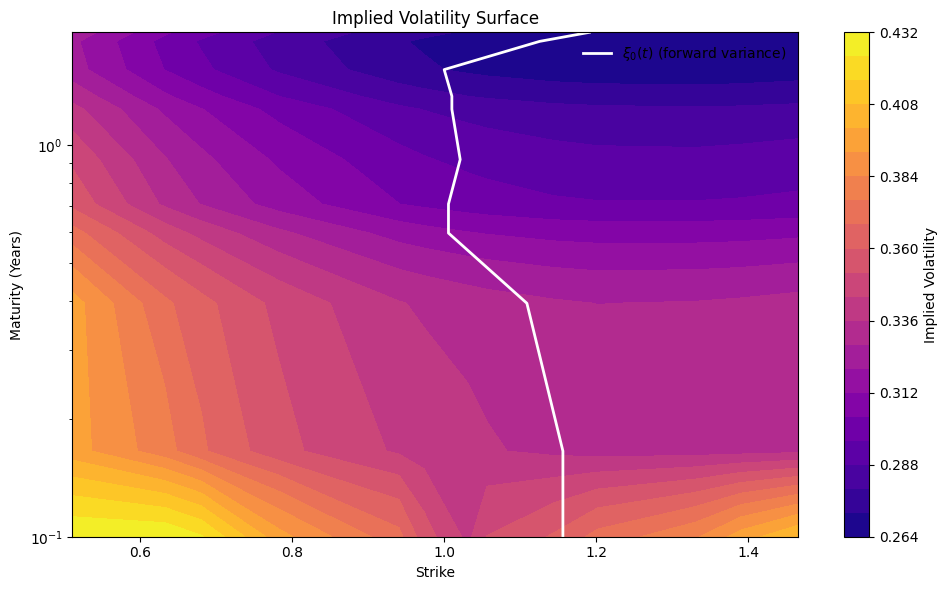

In [32]:
k = 225
x = surfaces[k]["iv_surface"]
xi0_knots = np.array(surfaces[k]["params"]["xi0_knots"])
maturities = np.array(surfaces[k]["grid"]["maturities"])
strikes = np.array(surfaces[k]["grid"]["strikes"])
x = repair_edges_local_directional(x, maturities, strikes)

# interpolate xi0 to the maturity grid
xi0_interp = np.interp(
    maturities,
    np.linspace(maturities.min(), maturities.max(), len(xi0_knots)),
    xi0_knots
)

plot_iv_surface(
    x,
    strikes,
    maturities,
    xi0_curve=xi0_interp,
    kind="contour"
)


In [31]:
x

array([[0.4307355 , 0.4307355 , 0.42472447, 0.39477631, 0.37032636,
        0.35572531, 0.34205435, 0.35213859, 0.36082531, 0.37064755,
        0.38281316, 0.39577389, 0.40793623],
       [0.39533349, 0.37924135, 0.36920055, 0.35439855, 0.34277974,
        0.3400444 , 0.33801576, 0.33673375, 0.33432316, 0.33284654,
        0.33278417, 0.33326427, 0.33437386],
       [0.39533349, 0.36961359, 0.36247298, 0.34954276, 0.33651968,
        0.33478137, 0.33233192, 0.33132211, 0.32897198, 0.32791821,
        0.32846671, 0.32924915, 0.33068895],
       [0.37114511, 0.34836939, 0.34142322, 0.32959611, 0.3169067 ,
        0.31505632, 0.312501  , 0.31158885, 0.30942768, 0.3086829 ,
        0.30866008, 0.30908056, 0.31029526],
       [0.35772629, 0.33453806, 0.3275698 , 0.3163901 , 0.30406207,
        0.30234896, 0.29990024, 0.29902251, 0.29699784, 0.29642463,
        0.29642061, 0.29676716, 0.29762801],
       [0.35035611, 0.32852677, 0.32186218, 0.3105174 , 0.29845517,
        0.29659944, 0.29414

In [23]:
maturities

array([0.1     , 0.165566, 0.395068, 0.597168, 0.708764, 0.920621,
       1.237473, 1.336776, 1.56282 , 1.845319, 1.946058])

In [11]:
# ============================================================
# Train the model
# ============================================================

# Prepare data loaders and collect normalization stats
train_loader, val_loader, branch_dim = DeepONet.prepare_data(surfaces, batch_size=256)

# Initialize and train model
model = DeepONet(branch_in_dim=branch_dim, trunk_in_dim=2, latent_dim=64, hidden_dim=64)
model._build_networks()

trainer = Trainer(model, train_loader, val_loader, lr=1e-3)
trainer.fit(epochs=20)

✅ Prepared data → 676000 train / 169000 val samples
Branch dim: 11, Trunk dim: 2


Epoch 01: train_rmse=0.030348, val_rmse=0.017866


Epoch 02: train_rmse=0.016622, val_rmse=0.015530


Epoch 03: train_rmse=0.015413, val_rmse=0.014521


Epoch 04: train_rmse=0.014805, val_rmse=0.014537


Epoch 05: train_rmse=0.014378, val_rmse=0.013856


Epoch 06: train_rmse=0.014105, val_rmse=0.013894


Epoch 07: train_rmse=0.013895, val_rmse=0.013337


Epoch 08: train_rmse=0.013734, val_rmse=0.013483


KeyboardInterrupt: 

MSE stats:
  mse_mean: 9.154843584325577e-05
  mse_std: 0.0002791412938513637
  mse_max: 0.003222099807346293
  rmse: 0.009568094681975914
  mae: 0.006932922334572303
  max_abs_error: 0.056763542942158685
  max_error_location: {'maturity_index': 0, 'strike_index': 0, 'strike': 0.520878, 'maturity': 0.02}
MSE stats:
  mse_mean: 0.00020264063043254422
  mse_std: 0.0005982787943021565
  mse_max: 0.004722759902186848
  rmse: 0.014235189862890633
  mae: 0.0091281529512275
  max_abs_error: 0.06872233917866044
  max_error_location: {'maturity_index': 4, 'strike_index': 0, 'strike': 0.5, 'maturity': 0.149488}
MSE stats:
  mse_mean: 0.00048387880930934223
  mse_std: 0.0019380325806418084
  mse_max: 0.016795266441516285
  rmse: 0.021997245493682663
  mae: 0.012715883969743325
  max_abs_error: 0.12959655258345526
  max_error_location: {'maturity_index': 0, 'strike_index': 0, 'strike': 0.520783, 'maturity': 0.02}
MSE stats:
  mse_mean: 0.00014220353150460374
  mse_std: 0.0003454891405932063
  mse_

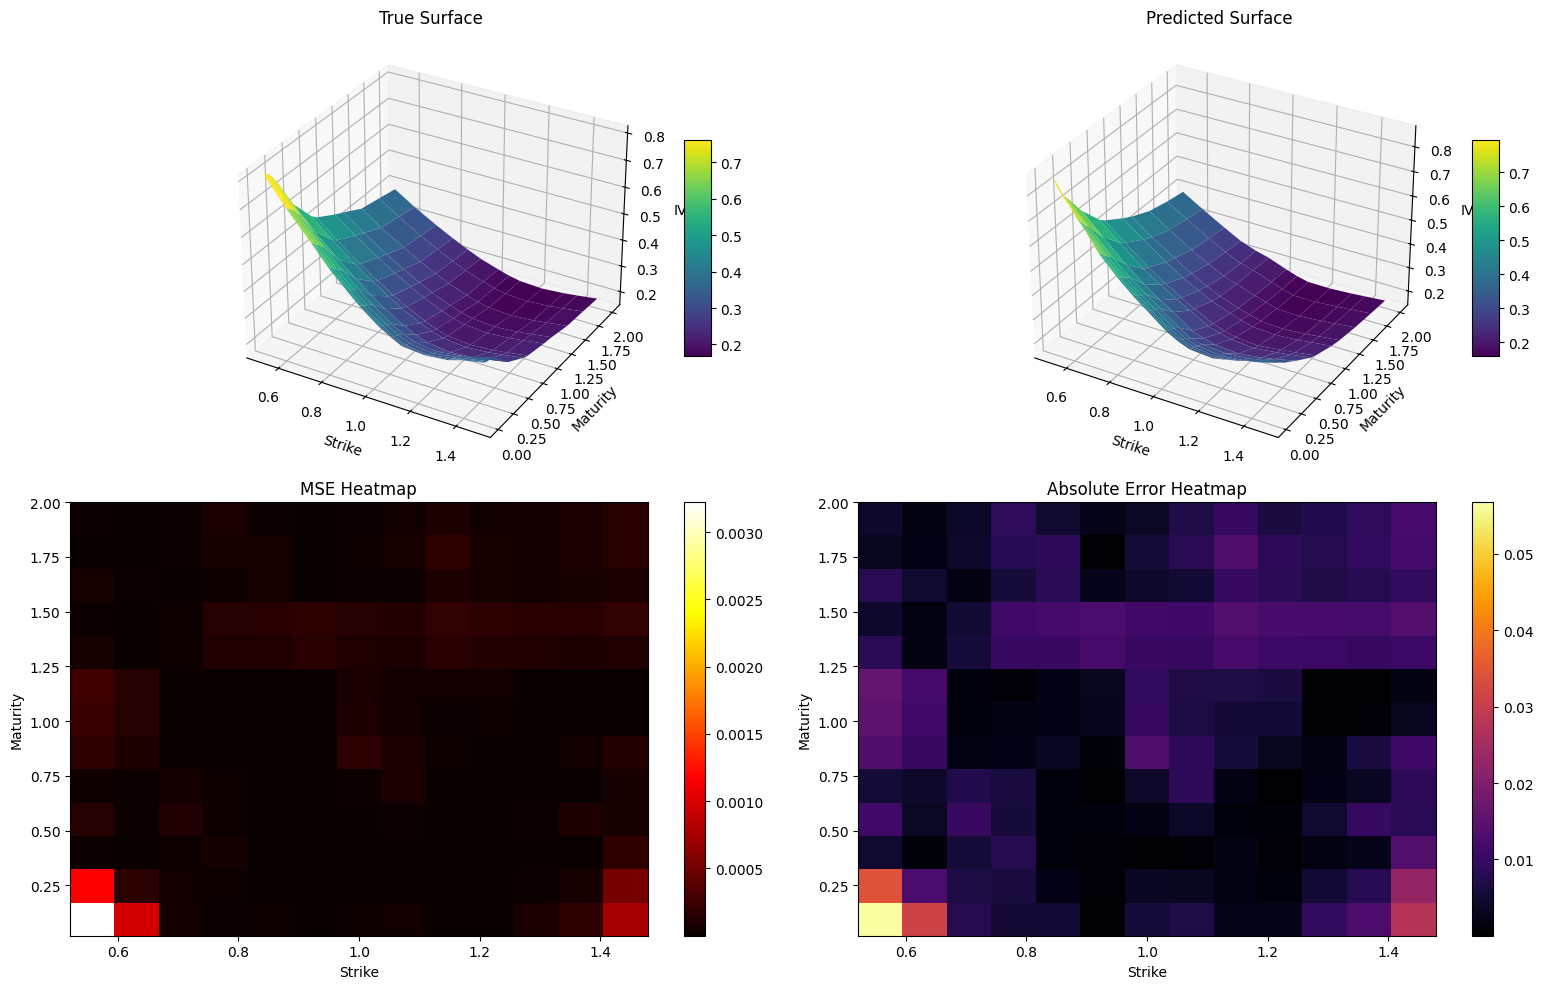

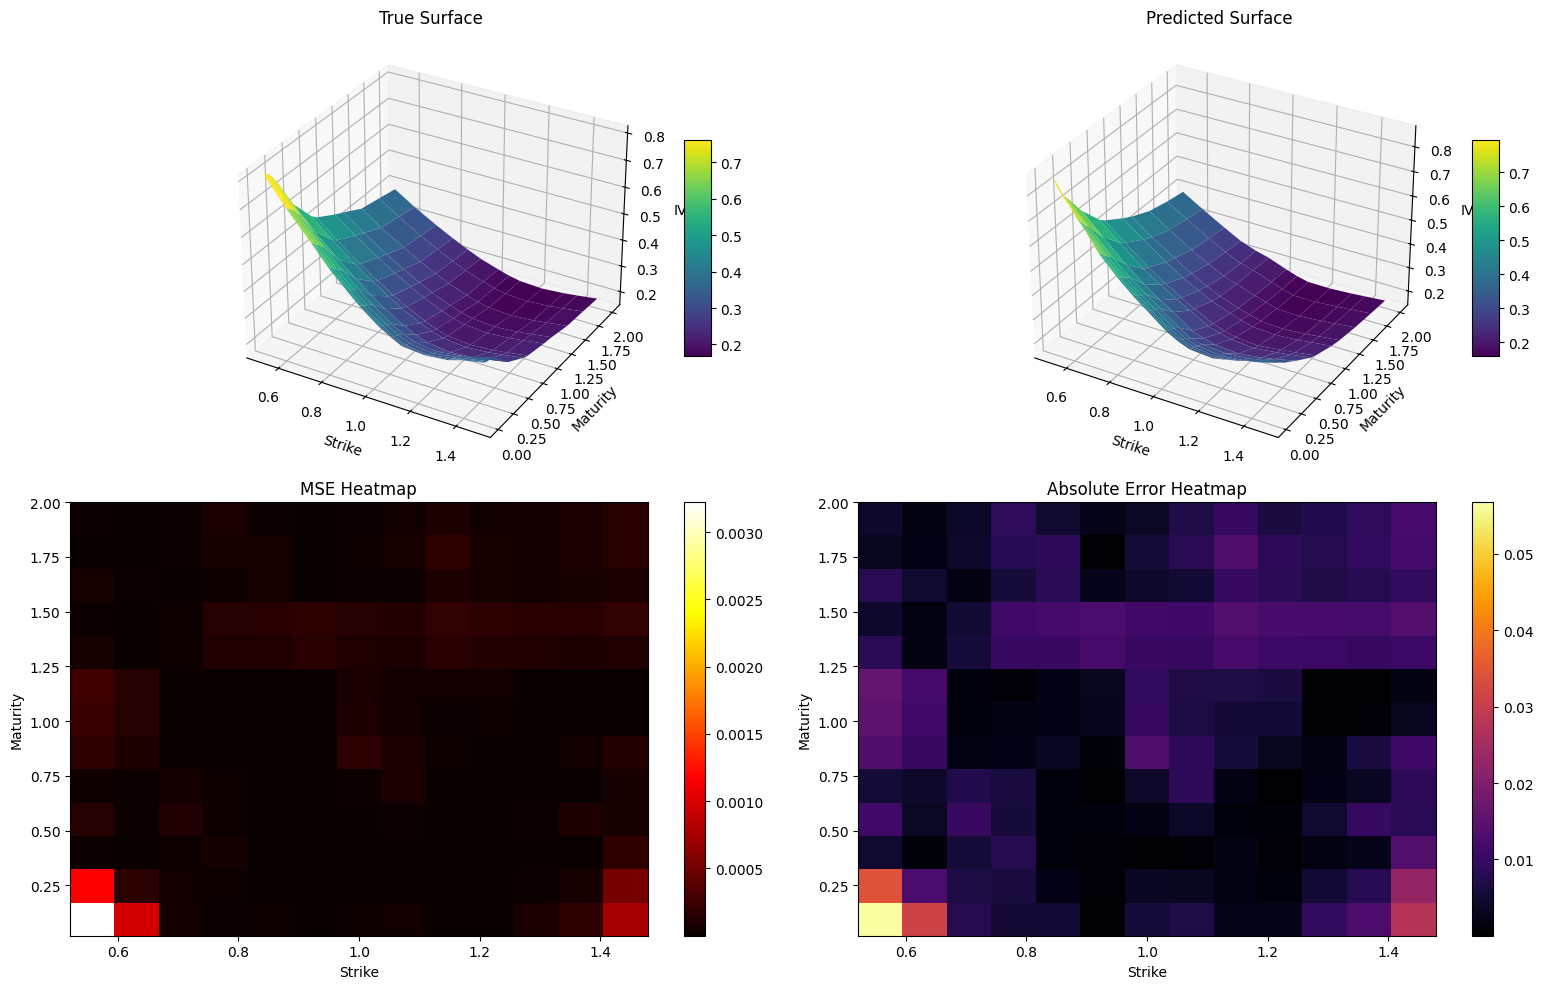

In [23]:
# ============================================================
# Evaluate the model
# ============================================================

# Create evaluator with training normalization stats
evaluator = ModelEvaluator(model)

# Select test samples for visualization
test_samples = surfaces[-400:-395]  # Use last 5 surfaces as test samples

# Create directory for evaluation plots
save_dir = os.path.join('data', datetime.now().strftime('%Y-%m-%d'), 'evaluation')
os.makedirs(save_dir, exist_ok=True)

# Generate evaluation plots
evaluator.evaluate_samples(test_samples, save_path=save_dir)
print(f"Evaluation plots saved to {save_dir}")

# Show an example plot in the notebook
evaluator.plot_evaluation(test_samples[0])  # Display first test sample's evaluation

# Consistency check 

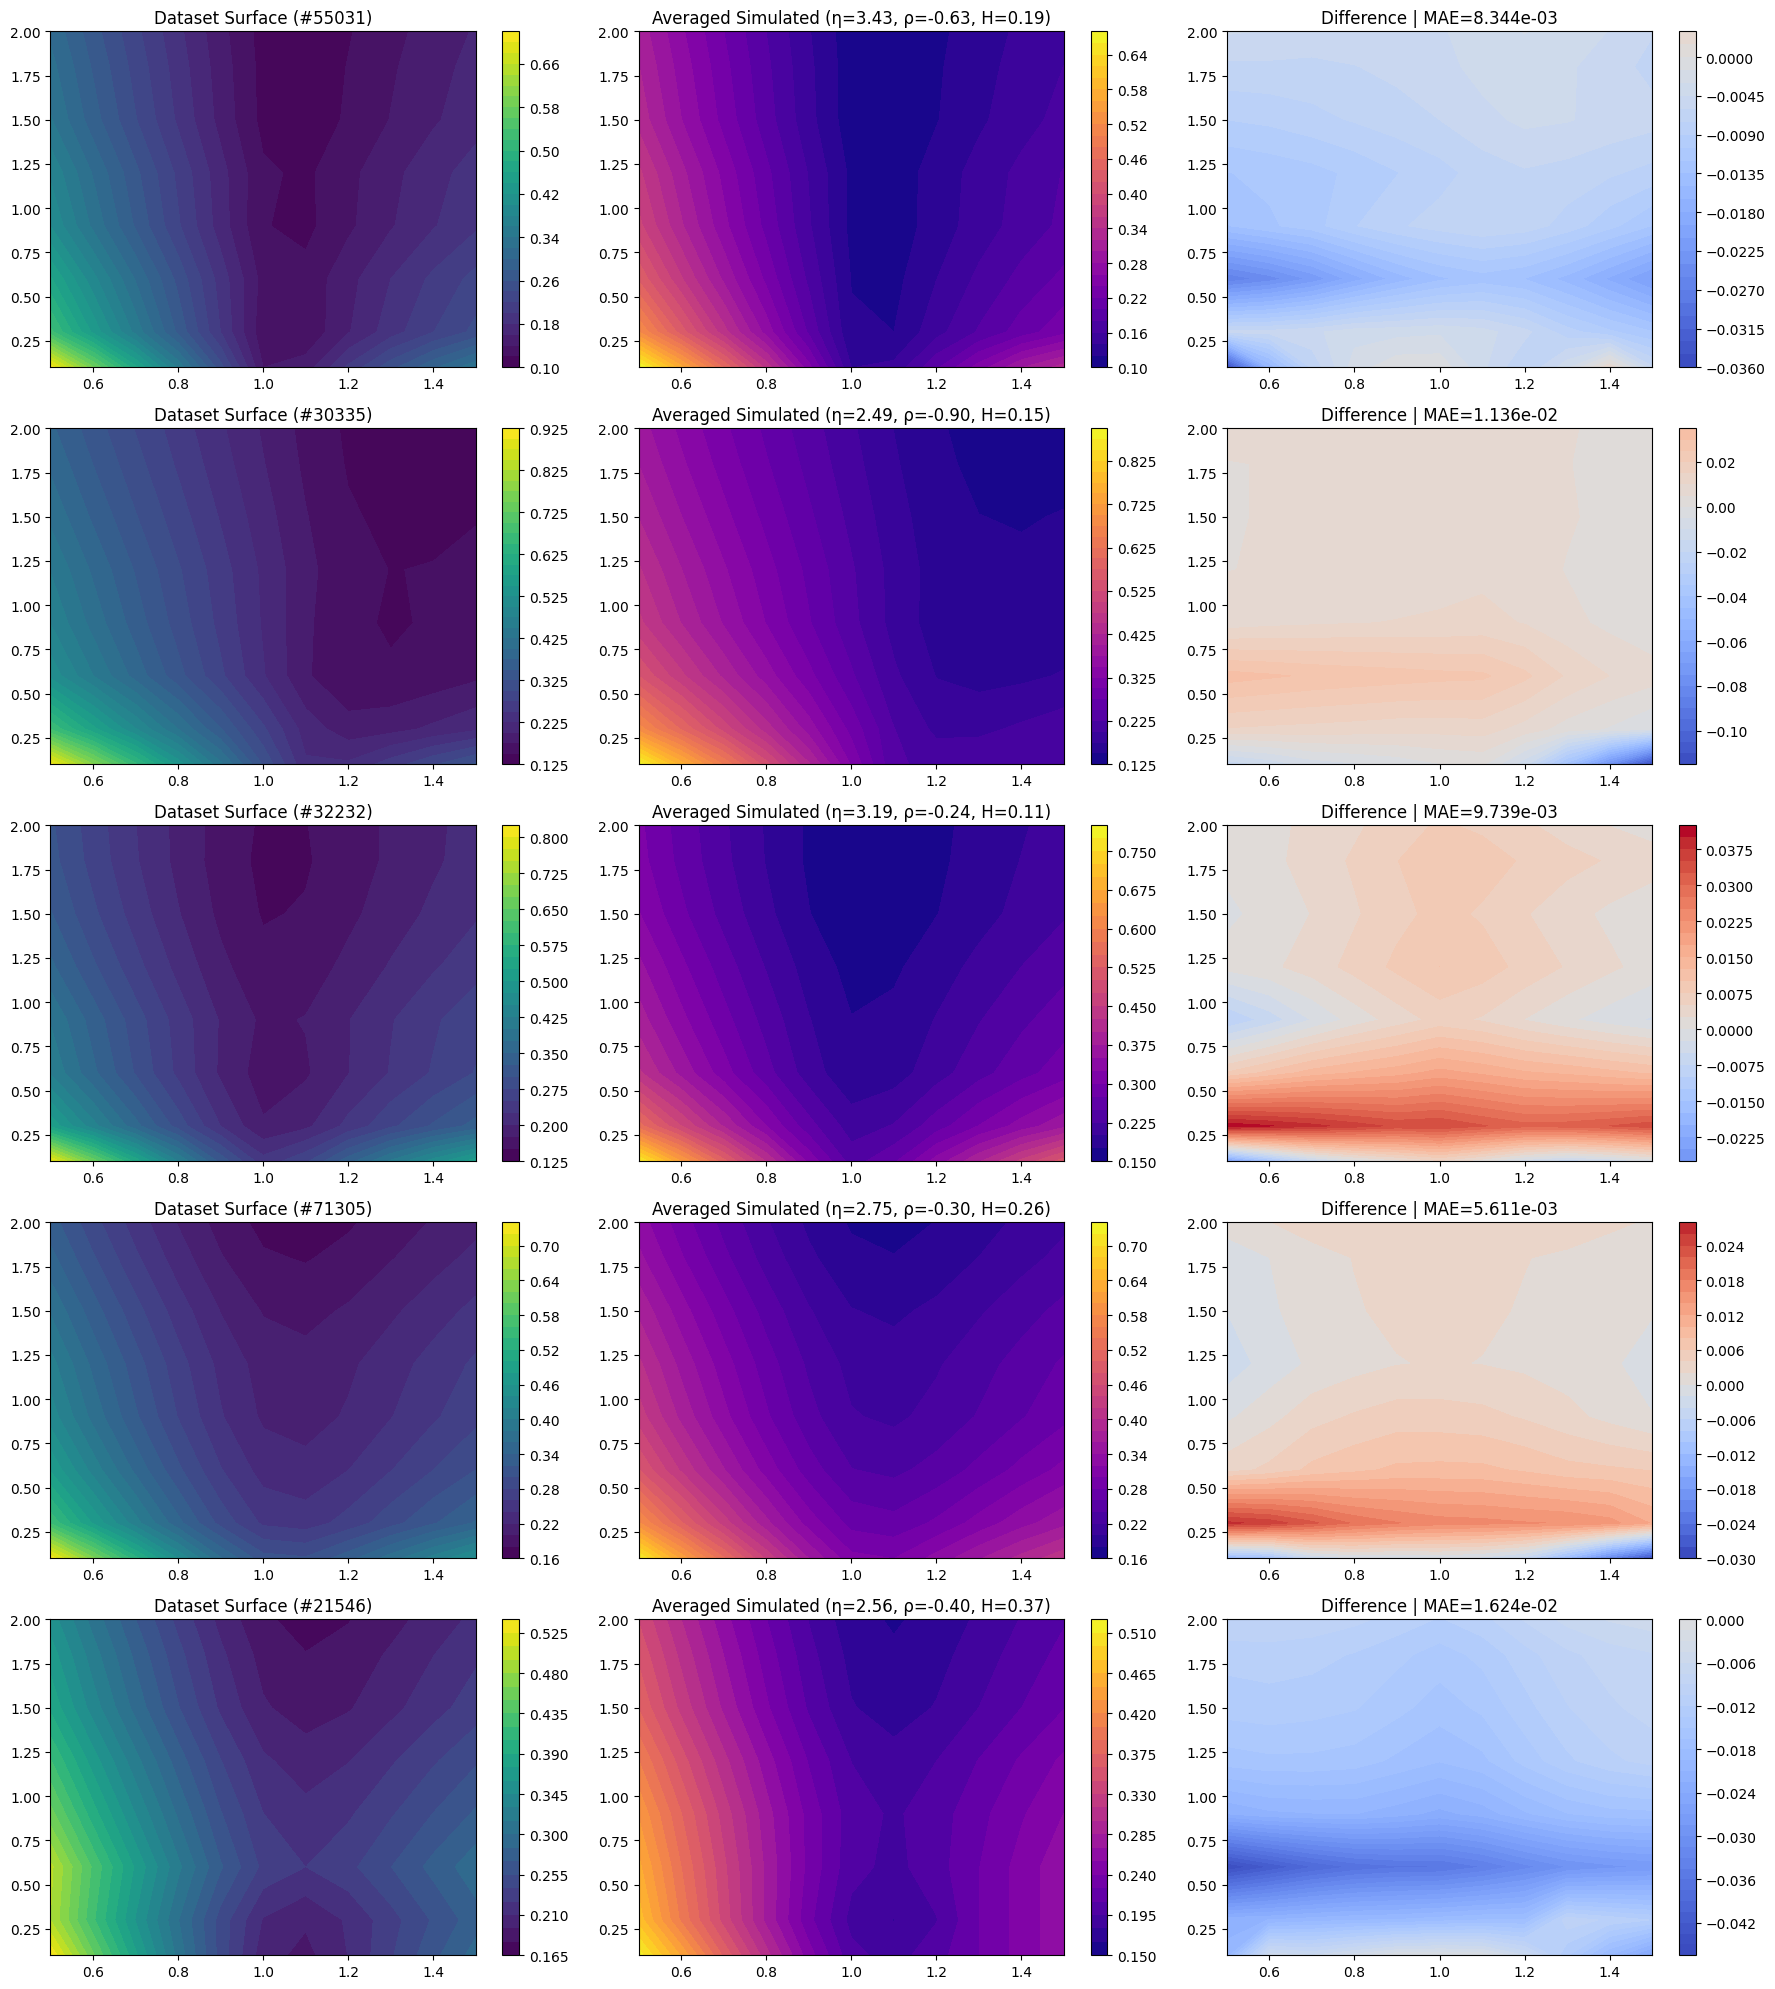

Comparison summary (averaged over seeds):
Idx 55031 | η=3.431, ρ=-0.630, H=0.187 | MAE=8.344e-03
Idx 30335 | η=2.493, ρ=-0.902, H=0.154 | MAE=1.136e-02
Idx 32232 | η=3.193, ρ=-0.245, H=0.112 | MAE=9.739e-03
Idx 71305 | η=2.747, ρ=-0.296, H=0.258 | MAE=5.611e-03
Idx 21546 | η=2.559, ρ=-0.401, H=0.369 | MAE=1.624e-02


In [2]:
import sys, os, gzip
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from generation.surface_generation import generate_fixed_surface, SimulationConfig

# ======================================================
# 1️⃣ Load data
# ======================================================

f = gzip.GzipFile("../OriginalCode/TrainrBergomiTermStructure.txt.gz", "r")
dat = np.load(f)
xx = dat[:, :11]
yy = dat[:, 11:]

strikes = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
maturities = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0])

cfg = SimulationConfig(M=50000, n=500, T_max=2.0, S0=1.0, G=1)

# ======================================================
# 2️⃣ Define subset of parameter sets to test
# ======================================================
num_tests = 5          # number of parameter combinations to test
num_seeds = 1        # how many seeds to average over
np.random.seed(143038)
test_indices = np.random.choice(len(xx), num_tests, replace=False)

# ======================================================
# 3️⃣ Run simulations and compare
# ======================================================
results = []
fig, axs = plt.subplots(num_tests, 3, figsize=(18, 4 * num_tests))
if num_tests == 1:
    axs = axs.reshape(1, -1)

for row, idx in enumerate(test_indices):
    xi0_knots = xx[idx, :8]
    eta, rho, H = xx[idx, 8:11]
    param_set = {"eta": float(eta), "rho": float(rho), "H": float(H)}

    # Average several random seeds
    sim_surfaces = []
    for s in range(num_seeds):
        seed_val = 400 + s * 17  # any deterministic spacing
        surf = generate_fixed_surface(param_set, xi0_knots, strikes, maturities, cfg, seed=seed_val)
        sim_surfaces.append(surf["iv_surface"])
    sim_surface = np.mean(sim_surfaces, axis=0)

    # True dataset surface
    true_surface = yy[idx].reshape(len(maturities), len(strikes))

    diff = sim_surface - true_surface
    mae = np.mean(np.abs(diff))
    results.append({"idx": idx, "eta": eta, "rho": rho, "H": H, "mae": mae})

    K, T = np.meshgrid(strikes, maturities)

    # Plot
    c0 = axs[row, 0].contourf(K, T, true_surface, levels=30, cmap="viridis")
    axs[row, 0].set_title(f"Dataset Surface (#{idx})")
    plt.colorbar(c0, ax=axs[row, 0])

    c1 = axs[row, 1].contourf(K, T, sim_surface, levels=30, cmap="plasma")
    axs[row, 1].set_title(f"Averaged Simulated (η={eta:.2f}, ρ={rho:.2f}, H={H:.2f})")
    plt.colorbar(c1, ax=axs[row, 1])

    vmax = np.max(np.abs(diff))
    c2 = axs[row, 2].contourf(K, T, diff, levels=30, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axs[row, 2].set_title(f"Difference | MAE={mae:.3e}")
    plt.colorbar(c2, ax=axs[row, 2])

plt.tight_layout()
plt.show()

# ======================================================
# 4️⃣ Print summary stats
# ======================================================
print("Comparison summary (averaged over seeds):")
for r in results:
    print(f"Idx {r['idx']:>4} | η={r['eta']:.3f}, ρ={r['rho']:.3f}, H={r['H']:.3f} | MAE={r['mae']:.3e}")


In [3]:
strikes

array([0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3, 1.4, 1.5])